In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score


df = pd.read_csv('Telco-Customer-Churn.csv') 

In [5]:
# Display the first ten rows
print("First 10 rows:")
print(df.head(10))

# Output column names
print("\nColumn Names:")
print(df.columns)

# Display data types
print("\nData Types:")
print(df.dtypes)

First 10 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service         

In [6]:
# Convert "TotalCharges" to numeric
# Note: In this specific dataset, TotalCharges often contains empty strings ' ' instead of NaN.
# errors='coerce' turns those invalid parsing results into NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove rows with missing values
df.dropna(inplace=True)

# Remove the "customerID" column
df.drop('customerID', axis=1, inplace=True)

# Convert "Churn" to binary (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert categorical variables to dummy variables
# We use drop_first=True to avoid the "dummy variable trap" (multicollinearity).
telecom_cust_dummies = pd.get_dummies(df, drop_first=True)

# Display the first few rows to verify
print(telecom_cust_dummies.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            Fa

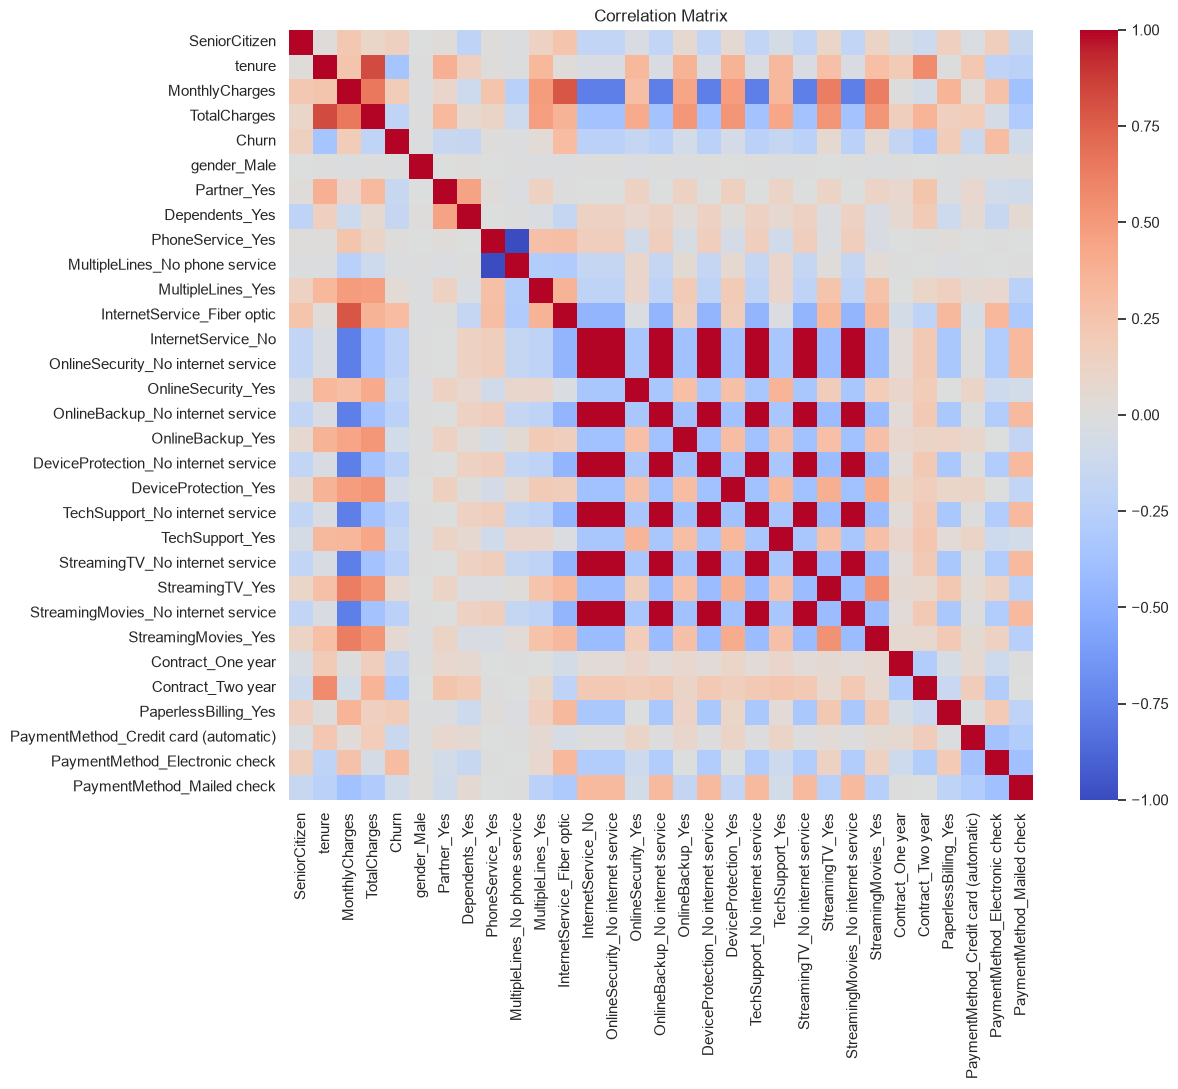

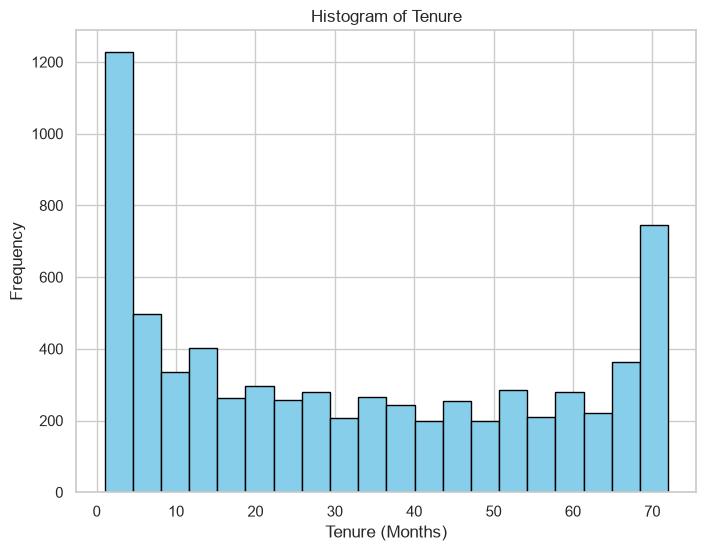

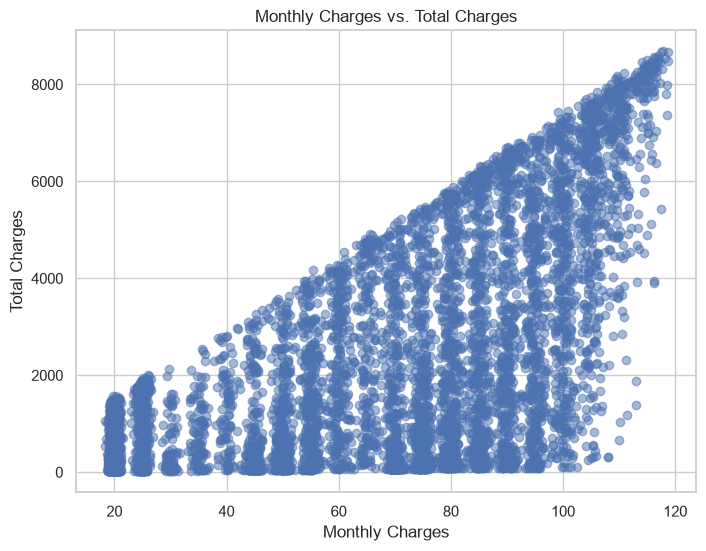

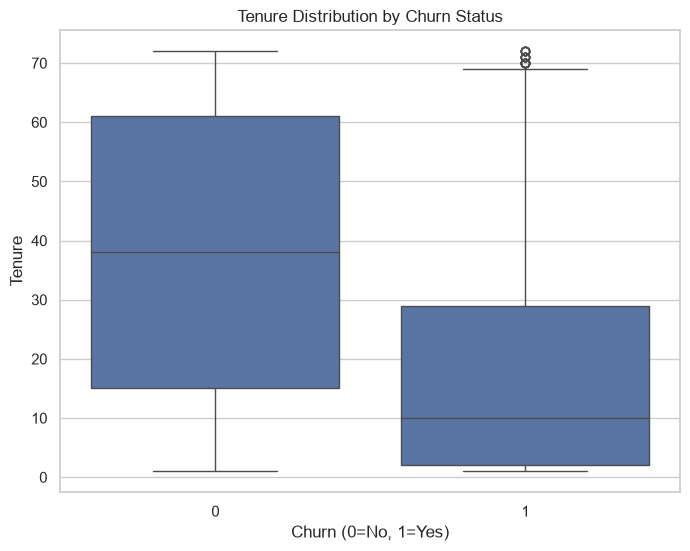

In [7]:
# Set plot style
sns.set(style="whitegrid")

# Correlation plot
plt.figure(figsize=(12, 10))
# We calculate correlation specifically against the 'Churn' column for clarity, 
# or a full heatmap. Here is a heatmap of the whole dataset.
corr_matrix = telecom_cust_dummies.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Histogram of "tenure"
plt.figure(figsize=(8, 6))
plt.hist(telecom_cust_dummies['tenure'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Frequency')
plt.show()

# Scatter plot of "MonthlyCharges" vs. "TotalCharges"
plt.figure(figsize=(8, 6))
plt.scatter(telecom_cust_dummies['MonthlyCharges'], telecom_cust_dummies['TotalCharges'], alpha=0.5)
plt.title('Monthly Charges vs. Total Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.show()

# Box plot to compare "tenure" for churned vs non-churned
plt.figure(figsize=(8, 6))
# Since we converted Churn to 0/1 in step 10, we plot against that column
sns.boxplot(x='Churn', y='tenure', data=telecom_cust_dummies)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Tenure')
plt.show()

In [9]:
# Separate features (X) and target (y)
# Note: 'Churn' is the target. All other columns are features.
X = telecom_cust_dummies.drop('Churn', axis=1)
y = telecom_cust_dummies['Churn']

# Scale all variables to 0-1 using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling (optional but good practice)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Split into training and test sets (25% test size)
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.25, random_state=42)

In [10]:
# Import and train Logistic Regression
log_reg = LogisticRegression(max_iter=1000) # Increased max_iter to ensure convergence
log_reg.fit(X_train, y_train)

# Make predictions
y_pred_log = log_reg.predict(X_test)

# Calculate and print accuracy
log_acc = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {log_acc:.4f}")

Logistic Regression Accuracy: 0.7912


In [11]:
# Create Random Forest Classifier with specific hyperparameters
rf_clf = RandomForestClassifier(
    n_estimators=2000,      # a. Number of trees
    oob_score=True,         # b. Enable OOB error estimation
    max_features='sqrt',    # c. Max features for splitting
    max_leaf_nodes=50,      # d. Max leaf nodes
    bootstrap=True,         # e. Activate bootstrapping
    random_state=42
)

# Fit the model
rf_clf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_clf.predict(X_test)

# Calculate and print accuracy
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

# Calculate and print OOB error estimation
# OOB Error = 1 - OOB Score
oob_error = 1 - rf_clf.oob_score_
print(f"OOB Score: {rf_clf.oob_score_:.4f}")
print(f"OOB Error: {oob_error:.4f}")
print("The OOB error gives us an estimate of how well the model generalizes to unseen data without needing a separate validation set.")

Random Forest Accuracy: 0.7935
OOB Score: 0.8074
OOB Error: 0.1926
The OOB error gives us an estimate of how well the model generalizes to unseen data without needing a separate validation set.


In [13]:
# Confusion Matrices
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Precision and Recall Scores
# We use average='binary' or default since Churn is 0/1, but 'macro' is safer for multi-class. 
# Since this is binary, default is fine.
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)

rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)

print(f"\nLogistic Regression - Precision: {log_precision:.4f}, Recall: {log_recall:.4f}")
print(f"Random Forest       - Precision: {rf_precision:.4f}, Recall: {rf_recall:.4f}")

# Discussion (You would write this in a Markdown cell, but here is the logic)
print("\n--- Analysis ---")
if rf_acc > log_acc:
    print("The Random Forest model has higher accuracy.")
else:
    print("The Logistic Regression model has higher accuracy.")

print("Compare the Recall scores specifically. In Churn prediction, Recall is often critical because we want to catch as many churning customers as possible (minimize False Negatives).")
print("If Random Forest has a significantly higher Recall, it is likely the more suitable model for retention strategies, even if Precision is slightly lower.")

Logistic Regression Confusion Matrix:
[[1154  146]
 [ 221  237]]

Random Forest Confusion Matrix:
[[1187  113]
 [ 250  208]]

Logistic Regression - Precision: 0.6188, Recall: 0.5175
Random Forest       - Precision: 0.6480, Recall: 0.4541

--- Analysis ---
The Random Forest model has higher accuracy.
Compare the Recall scores specifically. In Churn prediction, Recall is often critical because we want to catch as many churning customers as possible (minimize False Negatives).
If Random Forest has a significantly higher Recall, it is likely the more suitable model for retention strategies, even if Precision is slightly lower.
